In [1]:
# ============================================================
# CELL 1: IMPORTS FOR CNN TRAINING
# ============================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.15.0
GPU Available: []


In [2]:
# ============================================================
# CELL 2: SET DATA PATHS
# ============================================================

# Path to your images
BASE_PATH = 'data/Images/rice_plant_lacks_nutrients'

# Check folders exist
n_path = os.path.join(BASE_PATH, 'Nitrogen(N)')
p_path = os.path.join(BASE_PATH, 'Phosphorus(P)')
k_path = os.path.join(BASE_PATH, 'Potassium(K)')

print(f"Nitrogen folder exists: {os.path.exists(n_path)}")
print(f"Phosphorus folder exists: {os.path.exists(p_path)}")
print(f"Potassium folder exists: {os.path.exists(k_path)}")

# Count images in each folder
if os.path.exists(n_path):
    print(f"Nitrogen images: {len(os.listdir(n_path))}")
if os.path.exists(p_path):
    print(f"Phosphorus images: {len(os.listdir(p_path))}")
if os.path.exists(k_path):
    print(f"Potassium images: {len(os.listdir(k_path))}")

Nitrogen folder exists: True
Phosphorus folder exists: True
Potassium folder exists: True
Nitrogen images: 440
Phosphorus images: 333
Potassium images: 383


In [3]:
# ============================================================
# CELL 3: CREATE TRAIN/TEST FOLDER STRUCTURE
# ============================================================

import shutil
from sklearn.model_selection import train_test_split

# Create directories
DATASET_PATH = 'data/leaf_dataset'
os.makedirs(os.path.join(DATASET_PATH, 'train', 'nitrogen'), exist_ok=True)
os.makedirs(os.path.join(DATASET_PATH, 'train', 'phosphorus'), exist_ok=True)
os.makedirs(os.path.join(DATASET_PATH, 'train', 'potassium'), exist_ok=True)
os.makedirs(os.path.join(DATASET_PATH, 'test', 'nitrogen'), exist_ok=True)
os.makedirs(os.path.join(DATASET_PATH, 'test', 'phosphorus'), exist_ok=True)
os.makedirs(os.path.join(DATASET_PATH, 'test', 'potassium'), exist_ok=True)

print("Folder structure created!")

# Function to split and copy images
def split_and_copy(source_folder, class_name, test_size=0.2):
    images = os.listdir(source_folder)
    train_imgs, test_imgs = train_test_split(images, test_size=test_size, random_state=42)
    
    # Copy to train
    for img in train_imgs:
        src = os.path.join(source_folder, img)
        dst = os.path.join(DATASET_PATH, 'train', class_name, img)
        shutil.copy2(src, dst)
    
    # Copy to test
    for img in test_imgs:
        src = os.path.join(source_folder, img)
        dst = os.path.join(DATASET_PATH, 'test', class_name, img)
        shutil.copy2(src, dst)
    
    return len(train_imgs), len(test_imgs)

# Split each class
n_train, n_test = split_and_copy(n_path, 'nitrogen')
p_train, p_test = split_and_copy(p_path, 'phosphorus')
k_train, k_test = split_and_copy(k_path, 'potassium')

print(f"\nNitrogen - Train: {n_train}, Test: {n_test}")
print(f"Phosphorus - Train: {p_train}, Test: {p_test}")
print(f"Potassium - Train: {k_train}, Test: {k_test}")

Folder structure created!

Nitrogen - Train: 352, Test: 88
Phosphorus - Train: 266, Test: 67
Potassium - Train: 306, Test: 77


In [4]:
# ============================================================
# CELL 4: CREATE DATA GENERATORS WITH AUGMENTATION
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32

# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Test generator - NO augmentation, only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

# Load test data
test_generator = test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Show class mapping
print("\nClass mapping:", train_generator.class_indices)

Found 924 images belonging to 3 classes.
Found 232 images belonging to 3 classes.

Class mapping: {'nitrogen': 0, 'phosphorus': 1, 'potassium': 2}


In [5]:
# ============================================================
# CELL 5: BUILD CNN WITH TRANSFER LEARNING
# ============================================================

# Load pre-trained MobileNetV2 (without top classification layer)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze base model layers
base_model.trainable = False

# Build complete model
model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')  # 3 classes: N, P, K
])

# Compile
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 3)                

Training Phase 1 (Frozen Base)...
Epoch 1/20


29/29 [==============================] - 43s 1s/step - loss: 0.9378 - accuracy: 0.6061 - val_loss: 0.5349 - val_accuracy: 0.7974
Epoch 2/20
29/29 [==============================] - 33s 1s/step - loss: 0.5288 - accuracy: 0.7857 - val_loss: 0.3685 - val_accuracy: 0.8750
Epoch 3/20
29/29 [==============================] - 33s 1s/step - loss: 0.4104 - accuracy: 0.8377 - val_loss: 0.3698 - val_accuracy: 0.8836
Epoch 4/20
29/29 [==============================] - 32s 1s/step - loss: 0.3804 - accuracy: 0.8463 - val_loss: 0.3455 - val_accuracy: 0.8879
Epoch 5/20
29/29 [==============================] - 32s 1s/step - loss: 0.3589 - accuracy: 0.8755 - val_loss: 0.3234 - val_accuracy: 0.9009
Epoch 6/20
29/29 [==============================] - 32s 1s/step - loss: 0.3058 - accuracy: 0.8777 - val_loss: 0.3725 - val_accuracy: 0.8664
Epoch 7/20
29/29 [==============================] - 32s 1s/step - loss: 0.3317 - accuracy: 0.8788 - val_loss: 0.3710 - val_a

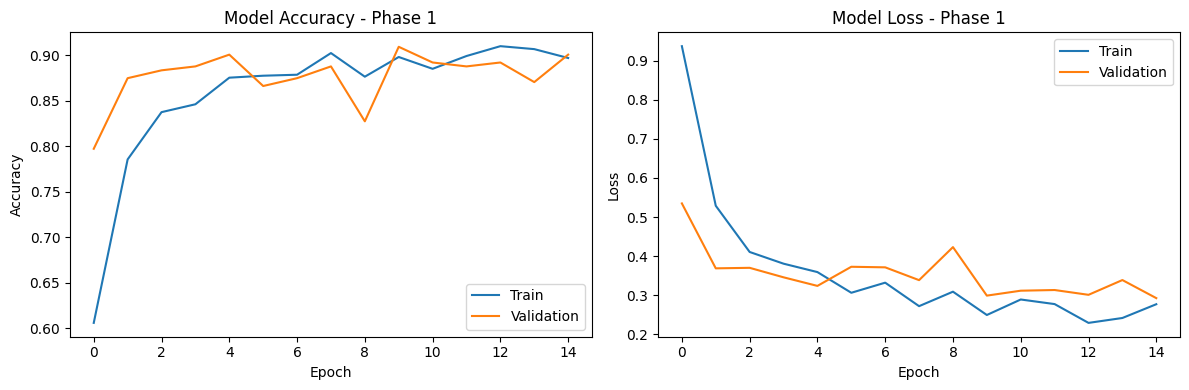

In [6]:
# ============================================================
# CELL 6: TRAIN THE MODEL (PHASE 1 - FROZEN BASE)
# ============================================================

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'models/leaf_cnn_phase1.keras',
    monitor='val_accuracy',
    save_best_only=True
)

print("Training Phase 1 (Frozen Base)...")
history1 = model.fit(
    train_generator,
    epochs=20,
    validation_data=test_generator,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history1.history['accuracy'], label='Train')
axes[0].plot(history1.history['val_accuracy'], label='Validation')
axes[0].set_title('Model Accuracy - Phase 1')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history1.history['loss'], label='Train')
axes[1].plot(history1.history['val_loss'], label='Validation')
axes[1].set_title('Model Loss - Phase 1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# CELL 7: SKIP FINE-TUNING - USE PHASE 1 MODEL
# ============================================================

# Load the best model from Phase 1
model = keras.models.load_model('models/leaf_cnn_phase1.keras')
print("Loaded Phase 1 model (best validation accuracy)")

# No fine-tuning - proceed directly to evaluation

Loaded Phase 1 model (best validation accuracy)


8/8 [==============================] - 6s 612ms/step
CLASSIFICATION REPORT
              precision    recall  f1-score   support

    nitrogen       0.93      0.94      0.94        88
  phosphorus       0.89      0.88      0.89        67
   potassium       0.90      0.90      0.90        77

    accuracy                           0.91       232
   macro avg       0.91      0.91      0.91       232
weighted avg       0.91      0.91      0.91       232



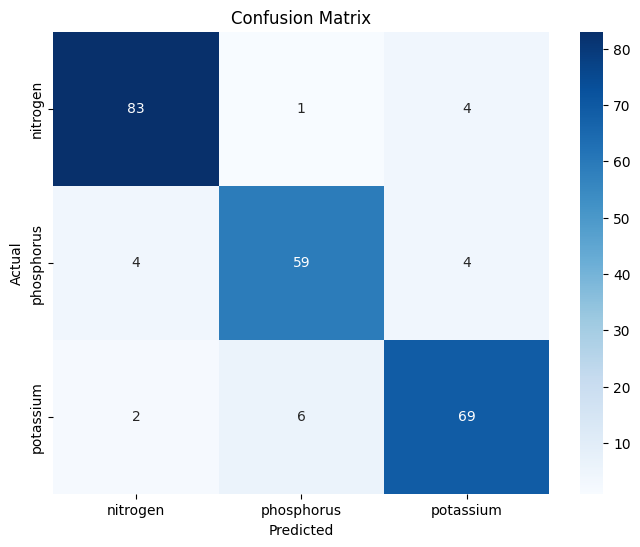


Model saved: models/leaf_cnn_final.h5


c:\Users\Abdul\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [8]:
# ============================================================
# CELL 8: EVALUATE MODEL
# ============================================================

# Get predictions
test_generator.reset()
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

# Class names
class_names = list(train_generator.class_indices.keys())

# Classification report
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save model
model.save('models/leaf_cnn_final.h5')
print("\nModel saved: models/leaf_cnn_final.h5")

In [9]:
# ============================================================
# CELL 9: EXTRACT FEATURES FROM CNN PENULTIMATE LAYER
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
import pandas as pd

# Create a model that outputs the penultimate layer (128 features)
feature_extractor = keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output  # The dense layer before final softmax
)

# Extract features for all test images
test_generator.reset()
features = feature_extractor.predict(test_generator, verbose=1)

# Get true labels
y_true = test_generator.classes

print(f"Extracted features shape: {features.shape}")
print(f"Number of features: {features.shape[1]}")
print(f"Number of samples: {features.shape[0]}")

8/8 [==============================] - 7s 715ms/step
Extracted features shape: (232, 128)
Number of features: 128
Number of samples: 232


In [10]:
# ============================================================
# CELL 10: FSMR ANALYSIS ON CNN FEATURES
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression

# Use the encoded labels (0, 1, 2) as target
y_target = y_true

# Calculate F-scores and p-values for each feature
f_scores, p_values = f_regression(features, y_target)

# Create results dataframe
fsmr_results = pd.DataFrame({
    'Feature_Index': range(features.shape[1]),
    'F_Score': f_scores,
    'P_Value': p_values,
    'Significant': p_values < 0.05,
    'Highly_Significant': p_values < 0.01
})

# Sort by F-score (higher = more important)
fsmr_results = fsmr_results.sort_values('F_Score', ascending=False)

print("=" * 70)
print("FSMR ANALYSIS ON CNN LEARNED FEATURES")
print("=" * 70)
print(f"\nTotal features analyzed: {len(fsmr_results)}")
print(f"Significant features (p<0.05): {fsmr_results['Significant'].sum()}")
print(f"Highly significant (p<0.01): {fsmr_results['Highly_Significant'].sum()}")
print(f"Non-significant (p>=0.05): {(~fsmr_results['Significant']).sum()}")

print("\n" + "-" * 70)
print("TOP 10 MOST SIGNIFICANT FEATURES")
print("-" * 70)
print(fsmr_results.head(10).to_string(index=False))

print("\n" + "-" * 70)
print("BOTTOM 10 LEAST SIGNIFICANT FEATURES")
print("-" * 70)
print(fsmr_results.tail(10).to_string(index=False))

FSMR ANALYSIS ON CNN LEARNED FEATURES

Total features analyzed: 128
Significant features (p<0.05): 76
Highly significant (p<0.01): 73
Non-significant (p>=0.05): 52

----------------------------------------------------------------------
TOP 10 MOST SIGNIFICANT FEATURES
----------------------------------------------------------------------
 Feature_Index    F_Score      P_Value  Significant  Highly_Significant
           118 302.645829 7.947213e-44         True                True
           101 290.748235 1.076947e-42         True                True
            77 282.021923 7.570254e-42         True                True
            96 277.013072 2.354079e-41         True                True
            65 254.736219 4.209294e-39         True                True
            29 230.144803 1.718030e-36         True                True
            54 229.913163 1.820902e-36         True                True
            58 229.026068 2.275758e-36         True                True
            

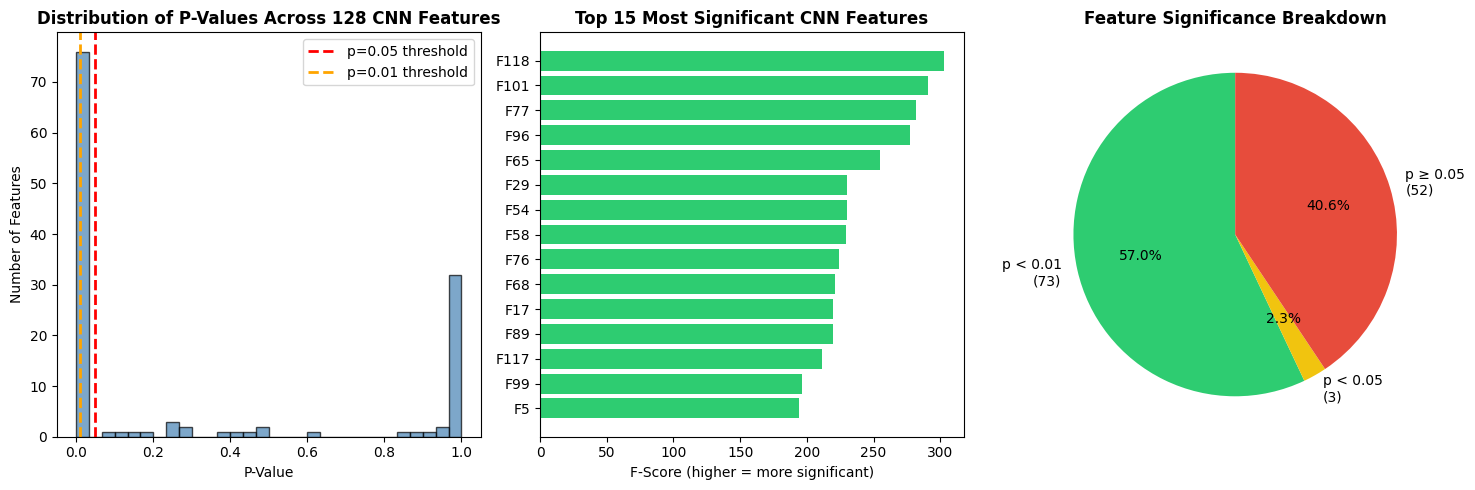


Saved: models/fsmr_cnn_analysis.png


In [11]:
# ============================================================
# CELL 11: VISUALIZE FSMR RESULTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: P-Value Distribution
axes[0].hist(p_values, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='p=0.05 threshold')
axes[0].axvline(x=0.01, color='orange', linestyle='--', linewidth=2, label='p=0.01 threshold')
axes[0].set_xlabel('P-Value')
axes[0].set_ylabel('Number of Features')
axes[0].set_title('Distribution of P-Values Across 128 CNN Features', fontweight='bold')
axes[0].legend()

# Plot 2: Top 15 Features by F-Score
top_15 = fsmr_results.head(15)
colors = ['#2ecc71' if p < 0.01 else '#f1c40f' if p < 0.05 else '#e74c3c' for p in top_15['P_Value']]
axes[1].barh(range(15), top_15['F_Score'], color=colors)
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f"F{i}" for i in top_15['Feature_Index']])
axes[1].set_xlabel('F-Score (higher = more significant)')
axes[1].set_title('Top 15 Most Significant CNN Features', fontweight='bold')
axes[1].invert_yaxis()

# Plot 3: Significance Summary Pie Chart
sig_counts = [
    fsmr_results['Highly_Significant'].sum(),
    fsmr_results['Significant'].sum() - fsmr_results['Highly_Significant'].sum(),
    (~fsmr_results['Significant']).sum()
]
labels = [f'p < 0.01\n({sig_counts[0]})', f'p < 0.05\n({sig_counts[1]})', f'p ≥ 0.05\n({sig_counts[2]})']
colors_pie = ['#2ecc71', '#f1c40f', '#e74c3c']
axes[2].pie(sig_counts, labels=labels, colors=colors_pie, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Feature Significance Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig('models/fsmr_cnn_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSaved: models/fsmr_cnn_analysis.png")

FSMR vs CNN FEATURE IMPORTANCE COMPARISON

Top 10 Features by FSMR vs their CNN Weights:
 Feature_Index  FSMR_F_Score  FSMR_P_Value  CNN_Avg_Weight
           118    302.645829  7.947213e-44        0.115348
           101    290.748235  1.076947e-42        0.075169
            77    282.021923  7.570254e-42        0.081079
            96    277.013072  2.354079e-41        0.144877
            65    254.736219  4.209294e-39        0.081986
            29    230.144803  1.718030e-36        0.137321
            54    229.913163  1.820902e-36        0.109314
            58    229.026068  2.275758e-36        0.070078
            76    224.050974  8.012218e-36        0.122979
            68    220.969520  1.759375e-35        0.076670

Correlation between FSMR F-Score and CNN Weight: -0.0480


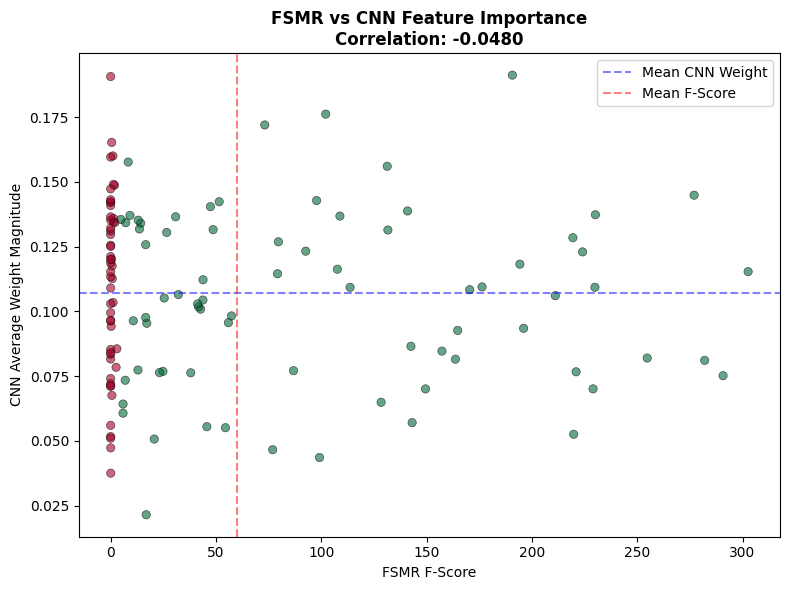

Saved: models/fsmr_cnn_correlation.png


In [12]:
# ============================================================
# CELL 12: COMPARE FSMR WITH CNN CLASS WEIGHTS
# ============================================================

# Get the weights from the final dense layer
final_layer = model.layers[-1]
weights = final_layer.get_weights()[0]  # Shape: (128, 3)

class_names = list(train_generator.class_indices.keys())

# Calculate average absolute weight per feature
feature_importance = np.abs(weights).mean(axis=1)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Feature_Index': range(128),
    'FSMR_F_Score': f_scores,
    'FSMR_P_Value': p_values,
    'CNN_Avg_Weight': feature_importance
})

# Sort by FSMR F-score
comparison_df = comparison_df.sort_values('FSMR_F_Score', ascending=False)

print("=" * 70)
print("FSMR vs CNN FEATURE IMPORTANCE COMPARISON")
print("=" * 70)
print("\nTop 10 Features by FSMR vs their CNN Weights:")
print(comparison_df.head(10).to_string(index=False))

# Correlation between FSMR and CNN importance
correlation = np.corrcoef(comparison_df['FSMR_F_Score'], comparison_df['CNN_Avg_Weight'])[0, 1]
print(f"\nCorrelation between FSMR F-Score and CNN Weight: {correlation:.4f}")

# Visualize correlation
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(comparison_df['FSMR_F_Score'], comparison_df['CNN_Avg_Weight'], 
           alpha=0.6, c=comparison_df['FSMR_P_Value'] < 0.05, 
           cmap='RdYlGn', edgecolors='black', linewidth=0.5)
ax.set_xlabel('FSMR F-Score')
ax.set_ylabel('CNN Average Weight Magnitude')
ax.set_title(f'FSMR vs CNN Feature Importance\nCorrelation: {correlation:.4f}', fontweight='bold')
ax.axhline(y=feature_importance.mean(), color='blue', linestyle='--', alpha=0.5, label='Mean CNN Weight')
ax.axvline(x=f_scores.mean(), color='red', linestyle='--', alpha=0.5, label='Mean F-Score')
ax.legend()
plt.tight_layout()
plt.savefig('models/fsmr_cnn_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: models/fsmr_cnn_correlation.png")

In [13]:
# ============================================================
# CELL 13: FSMR SUMMARY TABLE FOR THESIS
# ============================================================

summary_data = {
    'Metric': [
        'Total CNN Features Analyzed',
        'Significant Features (p<0.05)',
        'Highly Significant (p<0.01)',
        'Non-Significant (p>=0.05)',
        'Top Feature F-Score',
        'Median P-Value',
        'FSMR-CNN Correlation'
    ],
    'Value': [
        f"{len(fsmr_results)}",
        f"{fsmr_results['Significant'].sum()} ({(fsmr_results['Significant'].sum()/128*100):.1f}%)",
        f"{fsmr_results['Highly_Significant'].sum()} ({(fsmr_results['Highly_Significant'].sum()/128*100):.1f}%)",
        f"{(~fsmr_results['Significant']).sum()} ({((~fsmr_results['Significant']).sum()/128*100):.1f}%)",
        f"{fsmr_results.iloc[0]['F_Score']:.2f}",
        f"{np.median(p_values):.4f}",
        f"{correlation:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("=" * 60)
print("FSMR ANALYSIS - SUMMARY FOR THESIS")
print("=" * 60)
print(summary_df.to_string(index=False))

summary_df.to_csv('models/fsmr_summary.csv', index=False)
print("\nSaved: models/fsmr_summary.csv")

FSMR ANALYSIS - SUMMARY FOR THESIS
                       Metric      Value
  Total CNN Features Analyzed        128
Significant Features (p<0.05) 76 (59.4%)
  Highly Significant (p<0.01) 73 (57.0%)
    Non-Significant (p>=0.05) 52 (40.6%)
          Top Feature F-Score     302.65
               Median P-Value     0.0001
         FSMR-CNN Correlation    -0.0480

Saved: models/fsmr_summary.csv


In [14]:
# ============================================================
# CELL 14: LOAD AND DEMONSTRATE TRAINED MODEL
# ============================================================

# Load the saved model
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image

# Load model
model = load_model('models/leaf_cnn_final.h5')
print("Model loaded successfully!")
print(f"Model input shape: {model.input_shape}")
print(f"Model output classes: {list(train_generator.class_indices.keys())}")

# Model summary
model.summary()

Model loaded successfully!
Model input shape: (None, 224, 224, 3)
Model output classes: ['nitrogen', 'phosphorus', 'potassium']
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0    

In [15]:
# ============================================================
# CELL 15: TEST MODEL ON A SINGLE IMAGE
# ============================================================

import numpy as np
from tensorflow.keras.preprocessing import image

def predict_leaf(img_path, model, class_names):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Normalize
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class] * 100
    
    # Show results
    print(f"Image: {img_path}")
    print(f"Predicted: {class_names[predicted_class]}")
    print(f"Confidence: {confidence:.1f}%")
    print("\nAll probabilities:")
    for i, cls in enumerate(class_names):
        print(f"  {cls}: {predictions[0][i]*100:.1f}%")
    
    return predicted_class, confidence

# Test on one image from your test set
class_names = list(train_generator.class_indices.keys())

# Pick a test image (adjust path as needed)
test_img_path = 'data/leaf_dataset/test/nitrogen/untitled-1.JPG'  # Change to actual image

if os.path.exists(test_img_path):
    predict_leaf(test_img_path, model, class_names)
else:
    print(f"Image not found. Please update path.")
    print("Example test images in: data/leaf_dataset/test/")

Image: data/leaf_dataset/test/nitrogen/untitled-1.JPG
Predicted: nitrogen
Confidence: 97.3%

All probabilities:
  nitrogen: 97.3%
  phosphorus: 2.3%
  potassium: 0.4%


In [18]:
model.save('models/leaf_cnn_final.keras')
